<a href="https://colab.research.google.com/github/harshit-538/ML-DL/blob/main/8_Data_Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Data Augmentation:**
  - In CNN accuracy was low because all images in training dataset was central and not rotated or swapped.
  - So they are not scaled or rotated invariant.
  - To handle this problem we do data augmentation so basically it generated new rotated/scaled images from existing data.

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [8]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file('flower_photos', origin = dataset_url,cache_dir=".", untar=True)

In [9]:
data_dir

'./datasets/flower_photos'

In [11]:
import pathlib
data_dir = pathlib.Path(data_dir+'/flower_photos')
data_dir

PosixPath('datasets/flower_photos/flower_photos')

In [12]:
img_count = len(list(data_dir.glob('*/*.jpg')))
img_count

3670

In [13]:
roses = list(data_dir.glob('roses/*'))
print(len(roses))

641


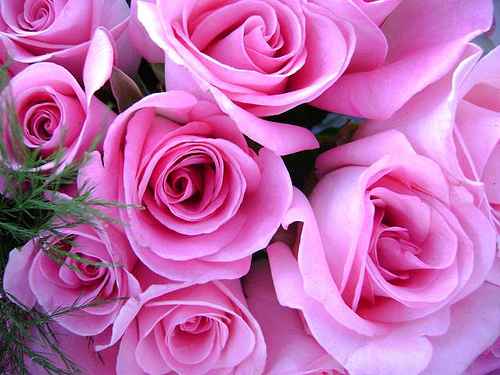

In [11]:
PIL.Image.open(str(roses[5]))

In [14]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy':list(data_dir.glob('daisy/*')),
    'dandelion':list(data_dir.glob('dandelion/*')),
    'sunflowers':list(data_dir.glob('sunflowers/*')),
    'tulips':list(data_dir.glob('tulips/*')),
}

In [15]:
flowers_labels_dict = {
    'roses':0,
    'daisy':1,
    'dandelion':2,
    'sunflowers':3,
    'tulips':4,
}

In [16]:
img = cv2.imread(flowers_images_dict['roses'][0])
img.shape

(240, 239, 3)

In [15]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [16]:
X,y = [],[]

#We first read image and resize it so we have same size images.
for flower_name, images in flowers_images_dict.items():
  for image in images:
    img = cv2.imread(str(image))
    resized_img = cv2.resize(img,(180,180))
    X.append(resized_img)
    y.append(flowers_labels_dict[flower_name])

In [17]:
X = np.array(X)
y = np.array(y)

In [18]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0)

In [19]:
X_train.shape , X_test.shape

((2752, 180, 180, 3), (918, 180, 180, 3))

In [20]:
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [21]:
model = Sequential([
    layers.Conv2D(16,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(64,activation='relu'),
    layers.Dense(5,activation='sigmoid')
])

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.fit(X_train_scaled,y_train,epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.3262 - loss: 1.5020
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5763 - loss: 1.0443
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6768 - loss: 0.8298
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7611 - loss: 0.6341
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8589 - loss: 0.4200
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9192 - loss: 0.2441
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9742 - loss: 0.1086
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9793 - loss: 0.0756
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9890 - loss: 0.0357
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9918 - loss: 0.0289
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9956 - loss: 0.0185
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy:

In [22]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6466 - loss: 3.1852


[2.8540515899658203, 0.6666666865348816]

In [23]:
predictions = model.predict(X_test_scaled)
predictions

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


array([[1.0579198e-01, 1.0000000e+00, 9.8524511e-02, 1.5510254e-07,
        3.2858270e-01],
       [1.0000000e+00, 8.8859594e-01, 1.3466957e-03, 7.3611277e-09,
        9.9333572e-01],
       [5.4480327e-09, 3.2981527e-06, 9.9999881e-01, 9.9975902e-01,
        2.1571564e-04],
       ...,
       [9.1040949e-04, 2.7601295e-03, 1.5466550e-01, 9.9995685e-01,
        4.3987324e-03],
       [1.9968189e-01, 1.3147569e-02, 8.2020711e-07, 1.6767895e-04,
        1.0000000e+00],
       [1.4694350e-08, 1.2516865e-02, 8.1799682e-03, 9.9962890e-01,
        9.9437827e-01]], dtype=float32)

In [24]:
score = tf.nn.softmax(predictions[0])
score

<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([0.15180661, 0.37122762, 0.15070735, 0.13656704, 0.18969132],
      dtype=float32)>

In [25]:
np.argmax(score)

np.int64(1)

In [26]:
y_test[0]

np.int64(1)

In [27]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal',input_shape=(180,180,3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


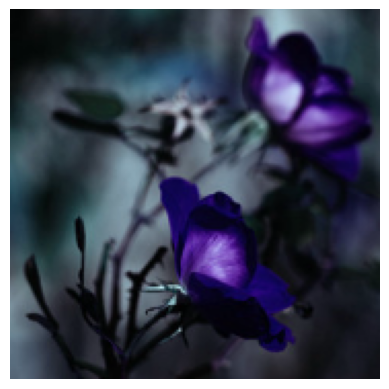

In [28]:
plt.axis('off')
plt.imshow(X[0])

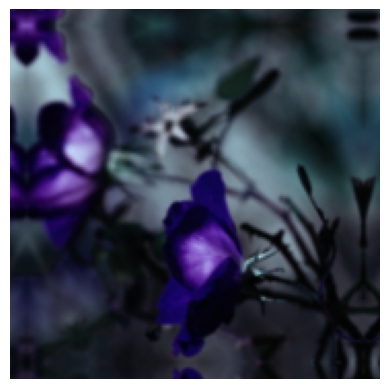

In [29]:
plt.axis('off')
plt.imshow(data_augmentation(X)[0].numpy().astype('uint8'))

In [30]:
num_classes = 5

model = Sequential([
    data_augmentation,
    layers.Conv2D(16,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(64,activation='relu'),
    layers.Dense(5,activation='sigmoid')
])

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.fit(X_train_scaled,y_train,epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.3989 - loss: 1.3597
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5660 - loss: 1.0699
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6396 - loss: 0.9278
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6408 - loss: 0.8959
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6809 - loss: 0.8156
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6936 - loss: 0.7756
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7164 - loss: 0.7215
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.7318 - loss: 0.7021
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.7420 - loss: 0.6547
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.7428 - loss: 0.6514
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.7594 - loss: 0.6322
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy:

In [31]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7102 - loss: 1.1315


[1.1186277866363525, 0.7244008779525757]

#**Transfer Learning:**
  - Take Existing pre-trained model and then train again with our data and use that for prediction.
  - We will use mobile net pre-trained model from google's tensorflow hub.
  - Mobilenet V2 model - 1.4 million training images and 1000 classes

In [5]:
import numpy as np
import cv2
import PIL.Image as Image
import os

import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [18]:
IMAGE_SHAPE = (224,224)

mobile_net_layer = hub.KerasLayer("https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4", input_shape = IMAGE_SHAPE+(3,))
classifier = tf.keras.Sequential([
    tf.keras.layers.Lambda(lambda x: mobile_net_layer(x), input_shape=(224, 224, 3)),
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


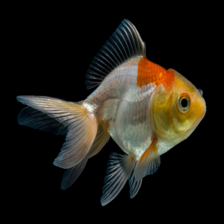

In [19]:
gold_fish = Image.open('goldfish.jpg').resize(IMAGE_SHAPE)
gold_fish

In [20]:
gold_fish = np.array(gold_fish)/255.0
gold_fish.shape

(224, 224, 3)

In [21]:
data_dir

PosixPath('datasets/flower_photos/flower_photos')

In [22]:
flowers_labels_dict

{'roses': 0, 'daisy': 1, 'dandelion': 2, 'sunflowers': 3, 'tulips': 4}

In [23]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))
cv2.resize(img,IMAGE_SHAPE).shape


(224, 224, 3)

In [24]:
X,y = [],[]

for flower_name, images in flowers_images_dict.items():
  for image in images:
    img = cv2.imread(str(image))
    resized_img = cv2.resize(img,IMAGE_SHAPE)
    X.append(resized_img)
    y.append(flowers_labels_dict[flower_name])


In [25]:
X = np.array(X)
y = np.array(y)

In [26]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0)

In [27]:
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [28]:
predicted = classifier.predict(np.array([X[0],X[1],X[2]]))
predicted = np.argmax(predicted,axis=1)
predicted

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


array([722, 795, 722])

In [30]:
feature_extraction_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

pretrained_model_without_top_layer = hub.KerasLayer(
    feature_extraction_model,input_shape=(224,224,3),trainable=False
  )

In [31]:
num_classes = 5
model = tf.keras.Sequential([
    tf.keras.layers.Lambda(lambda x: pretrained_model_without_top_layer(x), input_shape=(224, 224, 3)),
    tf.keras.layers.Dense(num_classes)
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,405 (25.02 KB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['accuracy']
)

model.fit(X_train_scaled,y_train,epochs=5)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.5451 - loss: 1.1755
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8544 - loss: 0.4314
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8792 - loss: 0.3448
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9087 - loss: 0.2820
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9338 - loss: 0.2372


In [33]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 379ms/step - accuracy: 0.8838 - loss: 0.3184


[0.34650787711143494, 0.8703703880310059]

#**Computer vision:**
  - **Image Classification:** Classify image wheather it is dog or not.

  - **Image Classification with Localization:** classify Image wheather it is dog or not with location(pixels)

  - **Object Detection:** If Image has multiple objects like dog/cat in one image that is called object detection.

  - **Image Segmentation:** Classifying each pixels in one of the classes is called image segmentation.

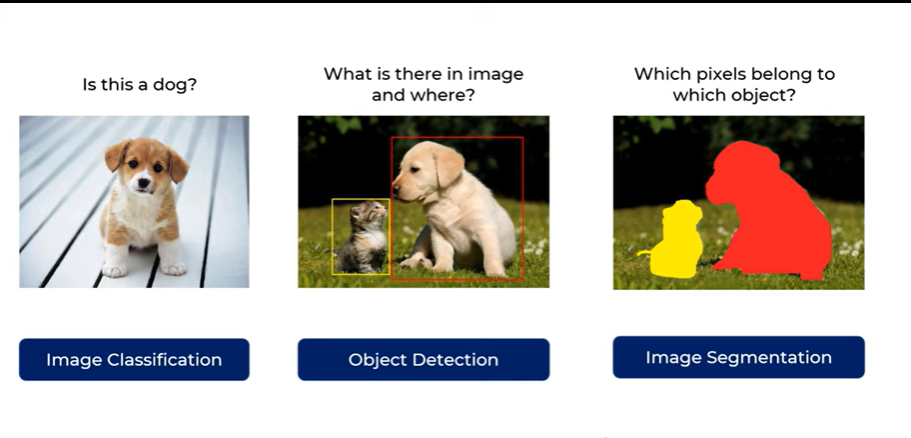